HW1 - COMS4726

In [76]:
import sys
print(sys.executable)

/Users/ethansmac/Downloads/DEEP_LEARNING_FOR_DS/.venv/bin/python


In [77]:
import sys
!{sys.executable} -m pip install ucimlrepo

1. Data Preparation
- Load the Forest Cover Type dataset.
- Select two cover types and convert the problem into binary classification.
- Split the data into 80% training and 20% testing sets.
- Standardize the features.

In [78]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
X = covertype.data.features 
y = covertype.data.targets 
  
# metadata 
print(covertype.metadata) 
  
# variable information 
print(covertype.variables)

{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [79]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [80]:
# Selecting two cover types: cover_type = 1, cover_type = 2
import pandas as pd
from sklearn.preprocessing import LabelEncoder
covertype_df = pd.concat([X, y], axis=1)

covertype_df = covertype_df[covertype_df['Cover_Type'].isin([1,2])]

# Convert the problem into binary classification
encoder = LabelEncoder()
covertype_df['cover_type_encoded'] = encoder.fit_transform(covertype_df['Cover_Type'])

In [81]:
# Split the data into 80% training and 20% testing sets.
from sklearn.model_selection import train_test_split
X_filtered = covertype_df.drop(columns=['Cover_Type', 'cover_type_encoded']) # has input features
y_filtered = covertype_df['cover_type_encoded'] # what we are predicting

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered,
                                                    test_size=0.2,
                                                    random_state=920,
                                                    shuffle=True)

In [82]:
# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train) # stores mean and std of training data, ensures scaling rules from training are applied to test w/o data leakage
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Perceptron
- Train a Perceptron classifier.
- Report accuracy, precision, recall, and F1-score.
- Visualize the decision boundary using two selected features.

In [84]:
# Training a Perceptron classifier

n = 1 # learning rate
error_count_train = 0

def step_function(z):
    if z > 0:
        return 1
    return 0

epoch = 0
max_epochs = 50

def perceptron_trainer(X_train_scaled, y_train, n, max_epochs):
    num_features = X_train_scaled.shape[1]
    w = [0] * num_features
    b = 0
    epoch = 0
    while epoch < max_epochs:
        error_count_train = 0
        epoch += 1
        for row in range(len(X_train_scaled)):
            z = X_train_scaled[row].dot(w) + b
            y_hat = step_function(z)
            error = y_train.iloc[row] - y_hat
            x_row = X_train_scaled[row]
            if error != 0:
                error_count_train += 1
                for i in range(len(w)):
                    w[i] = w[i] + n*error*x_row[i]
                b = b + n*error
        if error_count_train == 0:
            break
    return w, b
w, b = perceptron_trainer(X_train_scaled=X_train_scaled, 
                          y_train = y_train, 
                          n=1, 
                          max_epochs=50)

In [85]:
# Test data
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
error_count_test = 0

for row in range(len(X_test_scaled)):
        z = X_test_scaled[row].dot(w) + b
        y_hat = step_function(z)
        error = y_test.iloc[row] - y_hat
        x_row = X_test_scaled[row]
        if error != 0:
            error_count_test += 1
            if y_hat == 1:
                false_positive += 1
            else:
                false_negative += 1
        else:
            if y_hat == 1:
                true_positive += 1
            else:
                true_negative += 1

        

In [96]:
# Report accuracy, precision, recall, and F1-score.
accuracy = (len(X_test_scaled) - error_count_test) / len(X_test_scaled)

precision = true_positive / (true_positive + false_positive)

recall = true_positive / (true_positive + false_negative)

f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1_score)

Accuracy: 0.6089125407708853
Precision: 0.6687733248316862
Recall: 0.6286313637004654
F1-Score: 0.6480813441040971


In [87]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


0 2


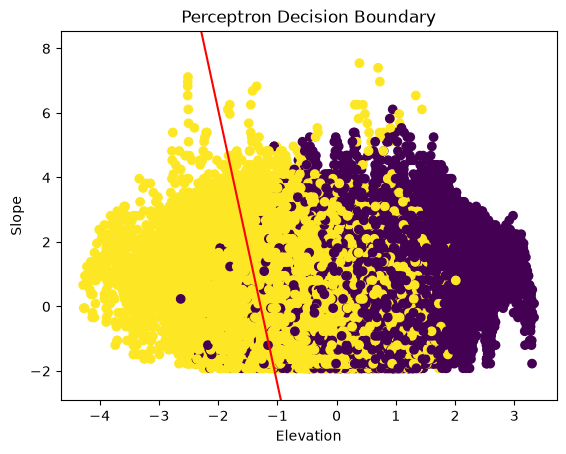

In [100]:
# Visualize the decision boundary using two selected features.
import matplotlib.pyplot as plt
import numpy as np
elevation_idx = X_train.columns.get_loc('Elevation')
slope_idx = X_train.columns.get_loc('Slope')
print(elevation_idx, slope_idx)

X_2feat = X_train_scaled[:, [elevation_idx, slope_idx]]
# Train the 2-Feature perceptron
w_2feat, b_2feat = perceptron_trainer(X_2feat, y_train, n=1, max_epochs = 50)

elevation_values = X_2feat[:, 0]
slope_values = X_2feat[:, 1]

x1_range = np.linspace(elevation_values.min(), elevation_values.max(), 100)
x2_boundary = -(w_2feat[0]*x1_range + b_2feat) / w_2feat[1] 

plt.scatter(elevation_values, slope_values, c = y_train)
plt.plot(x1_range, x2_boundary, color = 'red')
plt.xlabel('Elevation')
plt.ylabel('Slope')
plt.title('Perceptron Decision Boundary')
plt.ylim(slope_values.min() - 1, slope_values.max() + 1)
plt.show()

3. Logistic Regression
- Train a Logistic Regression classifier using the same data.
- Report accuracy, precision, recall, and F1-score.
- Visualize the decision boundary.

In [89]:
# Training Logistic Regression classifier
import math

def sigmoid_function(z):
    a = 1 / (1+math.e**(-z))
    return a

epsilon = 1e-10
def logistic_trainer(X_train_scaled, y_train, n, max_epochs):
    num_features = X_train_scaled.shape[1]
    w = [0] * num_features
    b = 0
    epoch = 0
    while epoch < max_epochs:
        epoch += 1
        total_loss = 0
        for row in range(len(X_train_scaled)):
            z = X_train_scaled[row].dot(w) + b
            y_hat = sigmoid_function(z)
            y = y_train.iloc[row]
            error = y - y_hat
            x_row = X_train_scaled[row]
            if error != 0:
                for i in range(len(w)):
                    w[i] = w[i] + n*error*x_row[i]
                b = b + n*error
            y_hat_clipped = max(epsilon, min(1 - epsilon, y_hat))  # makes sure that y_hat doesn't reach 0
            total_loss += -(y*math.log(y_hat_clipped) + (1-y)*math.log(1-y_hat_clipped))

        L = total_loss / len(X_train_scaled)
        if L < 0.0001:
            break
    return w, b


w_logistic, b_logistic = logistic_trainer(X_train_scaled=X_train_scaled, 
                                            y_train=y_train,
                                            n=0.01, # lower learning rate
                                            max_epochs=50)




In [90]:
# Report accuracy, precision, recall, and F1-score.

true_positive2 = 0
false_positive2 = 0
true_negative2 = 0
false_negative2 = 0
error_count_test2 = 0

bce_loss = 0

for row in range(len(X_test_scaled)):
        z = X_test_scaled[row].dot(w_logistic) + b_logistic
        y_hat = sigmoid_function(z)
        y_hat_clipped = max(epsilon, min(1 - epsilon, y_hat)) # For part 4, BCE loss
        y = y_test.iloc[row] 
        bce_loss += -(y*math.log(y_hat_clipped) + (1-y)*math.log(1-y_hat_clipped))
        if y_hat > 0.5:
             y_hat = 1
        else:
             y_hat = 0
        error = y_test.iloc[row] - y_hat
        x_row = X_test_scaled[row]
        if error != 0:
            error_count_test2 += 1
            if y_hat == 1:
                false_positive2 += 1
            else:
                false_negative2 += 1
        else:
            if y_hat == 1:
                true_positive2 += 1
            else:
                true_negative2 += 1

In [97]:
# Report accuracy, precision, recall, and F1-score.
accuracy_log = (len(X_test_scaled) - error_count_test2) / len(X_test_scaled)

precision_log = true_positive2 / (true_positive2 + false_positive2)

recall_log = true_positive2 / (true_positive2 + false_negative2)

f1_score_log = 2 * (precision_log * recall_log) / (precision_log + recall_log)

print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-Score:", f1_score_log)

Accuracy: 0.76427107211019
Precision: 0.7675171485351625
Recall: 0.8442039204625582
F1-Score: 0.8040361304187233


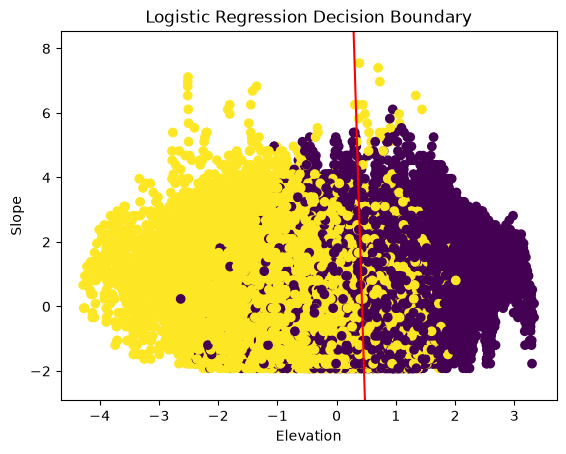

In [99]:
# Visualizing the decision boundary

X_2feat = X_train_scaled[:, [elevation_idx, slope_idx]]
# Train the 2-Feature perceptron
w_logistic_2feat, b_logistic_2feat = logistic_trainer(X_2feat, y_train, n=0.01, max_epochs = 50)

elevation_values = X_2feat[:, 0]
slope_values = X_2feat[:, 1]

x1_range = np.linspace(elevation_values.min(), elevation_values.max(), 100)
x2_boundary = -(w_logistic_2feat[0]*x1_range + b_logistic_2feat) / w_logistic_2feat[1] 

plt.scatter(elevation_values, slope_values, c = y_train)
plt.plot(x1_range, x2_boundary, color = 'red')
plt.xlabel('Elevation')
plt.ylabel('Slope')
plt.title('Logistic Regression Decision Boundary')
plt.ylim(slope_values.min() - 1, slope_values.max() + 1)
plt.show()

4. Binary Cross-Entropy (BCE)
- Calculate the BCE loss on the test set.
- Plot BCE loss as a function of predicted probability.

In [93]:
avg_bce_loss = bce_loss / len(X_test_scaled)
print(avg_bce_loss)

0.49684925895416954


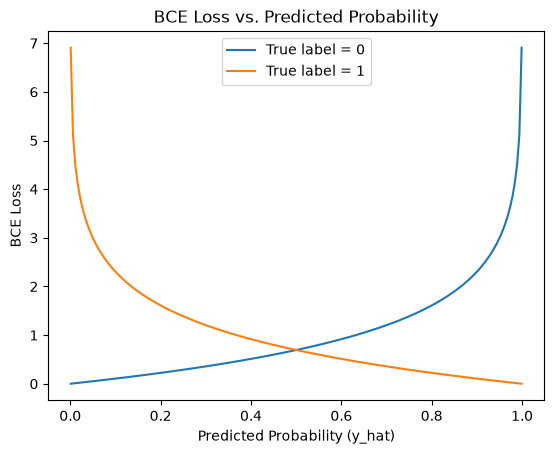

In [94]:
# Plot BCE loss as a function of predicted probability

y_hat_range = np.linspace(0.001, 0.999, 200)

def bce_loss(y, y_hat):
    return -(y*math.log(y_hat) + (1-y)*math.log(1-y_hat))

y_bce1 = 0
bce_list0 = [bce_loss(y_bce1, y_hat) for y_hat in y_hat_range]

y_bce2 = 1
bce_list1 = [bce_loss(y_bce2, y_hat) for y_hat in y_hat_range]

plt.plot(y_hat_range, bce_list0, label='True label = 0')
plt.plot(y_hat_range, bce_list1, label='True label = 1')
plt.xlabel('Predicted Probability (y_hat)')
plt.ylabel('BCE Loss')
plt.title('BCE Loss vs. Predicted Probability')
plt.legend()
plt.show()

5. Comparison
- Create a table comparing the Perceptron and Logistic Regression results.

In [98]:
comparison = pd.DataFrame({
    "Classifier": ['Perceptron', 'Logistic Regression'],
    "Accuracy": [round(accuracy, 5), round(accuracy_log, 5)],
    "Precision": [round(precision, 5), round(precision_log, 5)],
    "Recall": [round(recall, 5), round(recall_log, 5)],
    "F1-Score": [round(f1_score, 5), round(f1_score_log, 5)]
})
print(comparison)

            Classifier  Accuracy  Precision   Recall  F1-Score
0           Perceptron   0.60891    0.66877  0.62863   0.64808
1  Logistic Regression   0.76427    0.76752  0.84420   0.80404
